In [1]:
# 고전 컴퓨터비전 실습 — ④ 추적(Tracking) : SORT / DeepSORT
# (활용사례) 스포츠 선수 동선 분석, 매장 고객 동선 분석, 교통량·차량 속도 측정
#
# SORT(Simple Online and Realtime Tracking)는 "탐지(Detection) + 칼만필터
# (Kalman Filter, 운동 예측) + 매칭(Matching, 헝가리안 알고리즘)"의 조합으로
# 동작한다. DeepSORT는 여기에 "외형 특징(appearance feature)"을 추가해,
# 두 객체가 서로 가려지거나(occlusion) 교차할 때도 ID가 뒤바뀌지 않도록
# 보강한 버전이다.
#
# 실제 SORT/DeepSORT는 YOLO 같은 딥러닝 검출기와 사전학습 ReID 임베딩
# 네트워크를 사용하지만, 이는 인터넷에서 가중치를 내려받아야 해 Colab에서
# 바로 실행하기 어렵다. 이 실습에서는 "두 객체가 교차하며 서로를 가리는"
# 합성(synthetic) 영상을 직접 생성하고, 색상 기반 contour 탐지기(검출기 역할)
# + 색상 히스토그램(딥러닝 임베딩 대신 외형 특징 역할)을 사용해, SORT/DeepSORT
# 논문이 실제로 수행하는 "칼만필터 예측 → 헝가리안 매칭 → (DeepSORT는 외형
# 비용 추가)" 알고리즘 자체를 충실히 구현하고 동작을 직접 확인한다.
#
# Clean Architecture 레이어:
#   [도메인 계층]      — 값 객체(Detection/Track) + 추상 인터페이스
#                        (ObjectDetector/MotionModel/Associator). 외부 CV/최적화
#                        라이브러리에 의존하지 않는다.
#   [유스케이스 계층]   — MultiObjectTrackingUseCase. 트랙 생성·갱신·소멸이라는
#                        "추적 전체 흐름"만 조립하며, 구체 알고리즘은 모른다.
#   [인프라 계층]      — cv2 기반 탐지기, 칼만필터(수식), IoU/외형 매칭기,
#                        시각화를 구현한다.
#   [구성 루트]        — Colab 셀: 합성 영상 생성, DI 조립(SORT vs DeepSORT
#                        구성을 교체), 실행, 시각화·비교.

## 셀 1: 환경 준비

In [2]:
# !pip install opencv-python-headless scipy matplotlib numpy --quiet
from __future__ import annotations

import numpy as np
import matplotlib
from matplotlib import font_manager as _font_manager
import glob as _glob
_candidates = _glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic.ttf") + \
    _glob.glob("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc") + \
    _glob.glob("/usr/share/fonts/**/NotoSansCJK*.ttc", recursive=True)
_korean_font_name = "sans-serif"
for _font_path in _candidates:
    try:
        _font_manager.fontManager.addfont(_font_path)
        _korean_font_name = _font_manager.FontProperties(fname=_font_path).get_name()
        break
    except Exception:
        continue
matplotlib.rcParams["font.family"] = _korean_font_name
matplotlib.rcParams["axes.unicode_minus"] = False

# ===== [도메인 계층 / Domain Layer] =====
# cv2/scipy를 전혀 모르는 순수 계층. "추적이란 무엇을 입력받아 무엇을
# 돌려주는가"라는 계약만 정의한다.

from abc import ABC, abstractmethod
from dataclasses import dataclass, field


def compute_iou(bbox_a: tuple[float, float, float, float],
                 bbox_b: tuple[float, float, float, float]) -> float:
    """두 바운딩박스(x1,y1,x2,y2)의 IoU(Intersection over Union)를 계산하는
    순수 함수. 외부 라이브러리 없이 사칙연산만으로 구현한다."""
    ax1, ay1, ax2, ay2 = bbox_a
    bx1, by1, bx2, by2 = bbox_b
    inter_x1, inter_y1 = max(ax1, bx1), max(ay1, by1)
    inter_x2, inter_y2 = min(ax2, bx2), min(ay2, by2)
    inter_w, inter_h = max(0.0, inter_x2 - inter_x1), max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter_area
    return inter_area / union if union > 1e-6 else 0.0


@dataclass(frozen=True)
class Detection:
    """한 프레임에서 검출기가 내놓은 결과 1건. feature는 DeepSORT가 쓰는
    외형 벡터(이 실습에서는 색상 히스토그램), SORT는 사용하지 않는다."""
    bbox: tuple[float, float, float, float]  # (x1, y1, x2, y2)
    confidence: float
    feature: np.ndarray | None = None


@dataclass
class Track:
    """추적 중인 객체 하나의 상태. state는 칼만필터의 8차원 상태 벡터
    [cx, cy, w, h, vx, vy, vw, vh]이며, 이 값 자체의 갱신 방법(수식)은
    domain이 아니라 infra의 MotionModel 구현체가 안다 — Track은 "상태를
    담는 그릇"일 뿐이다."""
    track_id: int
    state: np.ndarray
    covariance: np.ndarray
    hits: int = 0
    age: int = 0
    time_since_update: int = 0
    feature: np.ndarray | None = None
    history: list[tuple[float, float]] = field(default_factory=list)

    @property
    def bbox(self) -> tuple[float, float, float, float]:
        cx, cy, w, h = self.state[:4]
        return (cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2)

    @property
    def is_confirmed(self) -> bool:
        return self.hits >= 3


class ObjectDetector(ABC):
    """"프레임을 받아 탐지 목록을 돌려준다"는 계약만 정의한다. 실제 서비스
    에서는 YOLO 등으로 교체되어도 유스케이스 코드는 바뀌지 않는다(OCP)."""

    @abstractmethod
    def detect(self, frame: np.ndarray) -> list[Detection]:
        ...


class MotionModel(ABC):
    """"칼만필터로 다음 위치를 예측하고, 실제 관측치로 보정한다"는 계약.
    SORT/DeepSORT 모두 같은 운동 모델을 공유한다."""

    @abstractmethod
    def initiate(self, bbox: tuple[float, float, float, float]) -> tuple[np.ndarray, np.ndarray]:
        ...

    @abstractmethod
    def predict(self, state: np.ndarray, covariance: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        ...

    @abstractmethod
    def update(self, state: np.ndarray, covariance: np.ndarray,
               bbox: tuple[float, float, float, float]) -> tuple[np.ndarray, np.ndarray]:
        ...


class Associator(ABC):
    """"현재 트랙들과 새 탐지들을 짝짓는다"는 계약. SORT(IoU만)와
    DeepSORT(IoU+외형)는 이 인터페이스의 서로 다른 구현체이며 완전히
    치환 가능하다(LSP) — 유스케이스는 어느 쪽이 주입되는지 모른다."""

    @abstractmethod
    def associate(
        self, tracks: list[Track], detections: list[Detection],
    ) -> tuple[list[tuple[int, int]], list[int], list[int]]:
        """반환값: (매칭된 (트랙idx, 탐지idx) 쌍 목록, 매칭 안 된 트랙 idx 목록,
        매칭 안 된 탐지 idx 목록)"""
        ...


class TrackGallery(ABC):
    """"오래 가려져 있다가 다시 나타난 객체를, 완전히 새로운 ID가 아니라
    원래 ID로 복구할 수 있는가"라는 책임만 갖는 작은 인터페이스(ISP).
    SORT는 외형 정보가 없어 이 기능을 수행할 수 없고(NullTrackGallery),
    DeepSORT는 사라지기 직전의 색상 특징을 잠시 기억해두었다가(갤러리)
    새 탐지와 비교해 같은 객체라면 ID를 재사용한다 — 이것이 DeepSORT가
    "긴 가려짐 이후에도 ID를 유지"할 수 있는 핵심 메커니즘이다."""

    @abstractmethod
    def remember(self, track: Track) -> None:
        """트랙이 삭제되기 직전, 나중에 재인식할 수 있도록 특징을 기억한다."""
        ...

    @abstractmethod
    def try_reidentify(self, detection: Detection) -> int | None:
        """매칭되지 않은 새 탐지가, 최근에 사라진 트랙과 같은 객체인지 확인해
        같다면 그 트랙 ID를, 아니라면 None을 돌려준다."""
        ...

    @abstractmethod
    def tick(self) -> None:
        """매 프레임 호출되어 갤러리에 보관된 기록의 나이를 늘리고, 너무
        오래된 기록은 제거한다."""
        ...


# ===== [유스케이스 계층 / Use Case Layer] =====
# cv2/scipy를 직접 호출하지 않고, 추상 인터페이스만으로 "추적"이라는
# 비즈니스 흐름(트랙 생성·갱신·소멸)을 조립한다.

class MultiObjectTrackingUseCase:
    def __init__(
        self,
        detector: ObjectDetector,
        motion_model: MotionModel,
        associator: Associator,
        gallery: TrackGallery,
        max_age: int = 8,
        feature_momentum: float = 0.9,
    ):
        self._detector = detector
        self._motion_model = motion_model
        self._associator = associator
        self._gallery = gallery
        self._max_age = max_age
        self._feature_momentum = feature_momentum
        self._tracks: list[Track] = []
        self._next_id = 1
        self.reidentified_log: list[tuple[int, int]] = []  # (새로 생성될 뻔한 시도, 복구된 기존 ID)

    def process_frame(self, frame: np.ndarray) -> list[Track]:
        self._gallery.tick()

        # 1) 예측: 모든 기존 트랙을 칼만필터로 한 스텝 전진
        for track in self._tracks:
            track.state, track.covariance = self._motion_model.predict(track.state, track.covariance)
            track.age += 1
            track.time_since_update += 1

        # 2) 탐지
        detections = self._detector.detect(frame)

        # 3) 매칭 (SORT: IoU만 / DeepSORT: IoU+외형 — associator 구현에 위임)
        matches, unmatched_tracks, unmatched_dets = self._associator.associate(self._tracks, detections)

        # 4) 매칭된 트랙은 관측치로 보정(갱신)
        for track_idx, det_idx in matches:
            track = self._tracks[track_idx]
            det = detections[det_idx]
            track.state, track.covariance = self._motion_model.update(track.state, track.covariance, det.bbox)
            track.hits += 1
            track.time_since_update = 0
            if det.feature is not None:
                if track.feature is None:
                    track.feature = det.feature
                else:
                    m = self._feature_momentum
                    track.feature = m * track.feature + (1 - m) * det.feature
            cx, cy = track.state[0], track.state[1]
            track.history.append((float(cx), float(cy)))

        # 5) 매칭 안 된 탐지는 — 먼저 "최근에 사라진 트랙"인지 갤러리에 물어보고
        # (재인식), 아니라면 그제서야 새 트랙으로 생성한다. SORT는 Null 갤러리를
        # 주입받으므로 이 단계가 항상 "새 트랙 생성"으로만 귀결된다.
        for det_idx in unmatched_dets:
            det = detections[det_idx]
            state, covariance = self._motion_model.initiate(det.bbox)
            recycled_id = self._gallery.try_reidentify(det)
            if recycled_id is not None:
                track_id = recycled_id
                self.reidentified_log.append((self._next_id, recycled_id))
            else:
                track_id = self._next_id
                self._next_id += 1
            new_track = Track(track_id=track_id, state=state, covariance=covariance,
                               hits=1, time_since_update=0, feature=det.feature)
            new_track.history.append((float(state[0]), float(state[1])))
            self._tracks.append(new_track)

        # 6) 오래 매칭되지 않은 트랙은 갤러리에 기억시킨 뒤 삭제
        survivors, expired = [], []
        for t in self._tracks:
            (survivors if t.time_since_update <= self._max_age else expired).append(t)
        for t in expired:
            self._gallery.remember(t)
        self._tracks = survivors

        return [t for t in self._tracks if t.is_confirmed or t.hits >= 1]


# ===== [인프라/어댑터 계층 / Infrastructure Layer] =====

import cv2
from scipy.optimize import linear_sum_assignment


class ColorContourDetector(ObjectDetector):
    """색상 기반 contour 탐지기 — 실제 딥러닝 검출기(YOLO 등) 대신, 이
    합성 영상에서 "전경 객체"를 찾아내는 역할을 한다. 각 contour의
    bbox와 함께, (DeepSORT용) 색상 히스토그램을 외형 특징으로 계산한다."""

    def __init__(self, min_area: int = 40, hist_bins: int = 16):
        self._min_area = min_area
        self._hist_bins = hist_bins

    def _color_histogram(self, frame: np.ndarray, bbox: tuple[float, float, float, float]) -> np.ndarray:
        x1, y1, x2, y2 = [int(round(v)) for v in bbox]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(frame.shape[1], x2), min(frame.shape[0], y2)
        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            return np.zeros(self._hist_bins * 3, dtype=np.float32)
        hist_channels = [cv2.calcHist([crop], [c], None, [self._hist_bins], [0, 256]) for c in range(3)]
        hist = np.concatenate(hist_channels).flatten()
        norm = np.linalg.norm(hist) + 1e-6
        return (hist / norm).astype(np.float32)

    def detect(self, frame: np.ndarray) -> list[Detection]:
        gray_sum = frame.sum(axis=2)
        foreground = (gray_sum > 60).astype(np.uint8) * 255  # 배경(검정)보다 밝은 모든 픽셀
        contours, _ = cv2.findContours(foreground, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        detections: list[Detection] = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < self._min_area:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            bbox = (float(x), float(y), float(x + w), float(y + h))
            # 신뢰도: 둘레 대비 contour 면적의 "꽉 참" 정도 — 다른 객체에
            # 가려져 찌그러진 모양일수록 값이 낮아지도록 설계(저신뢰 시뮬레이션)
            rect_area = w * h
            confidence = float(np.clip(area / max(rect_area, 1.0), 0.0, 1.0))
            feature = self._color_histogram(frame, bbox)
            detections.append(Detection(bbox=bbox, confidence=confidence, feature=feature))
        return detections


class ConstantVelocityKalmanMotionModel(MotionModel):
    """등속(constant-velocity) 운동을 가정하는 표준 선형 칼만필터. 상태
    벡터는 [cx, cy, w, h, vx, vy, vw, vh] 8차원이며, SORT 논문의 운동
    모델(위치+크기+각각의 변화율)을 그대로 따른다."""

    def __init__(self, process_noise: float = 1.0, measurement_noise: float = 1.0):
        self._dim = 8
        self._F = np.eye(self._dim)
        for i in range(4):
            self._F[i, i + 4] = 1.0  # cx += vx, cy += vy, w += vw, h += vh
        self._H = np.zeros((4, self._dim))
        for i in range(4):
            self._H[i, i] = 1.0
        self._Q = np.eye(self._dim) * process_noise
        self._R = np.eye(4) * measurement_noise

    def initiate(self, bbox: tuple[float, float, float, float]) -> tuple[np.ndarray, np.ndarray]:
        x1, y1, x2, y2 = bbox
        cx, cy, w, h = (x1 + x2) / 2, (y1 + y2) / 2, x2 - x1, y2 - y1
        state = np.array([cx, cy, w, h, 0, 0, 0, 0], dtype=np.float64)
        covariance = np.eye(self._dim) * 10.0
        return state, covariance

    def predict(self, state: np.ndarray, covariance: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        state = self._F @ state
        covariance = self._F @ covariance @ self._F.T + self._Q
        return state, covariance

    def update(self, state: np.ndarray, covariance: np.ndarray,
               bbox: tuple[float, float, float, float]) -> tuple[np.ndarray, np.ndarray]:
        x1, y1, x2, y2 = bbox
        measurement = np.array([(x1 + x2) / 2, (y1 + y2) / 2, x2 - x1, y2 - y1])

        innovation = measurement - self._H @ state
        innovation_cov = self._H @ covariance @ self._H.T + self._R
        kalman_gain = covariance @ self._H.T @ np.linalg.inv(innovation_cov)

        state = state + kalman_gain @ innovation
        covariance = (np.eye(self._dim) - kalman_gain @ self._H) @ covariance
        return state, covariance


class IoUHungarianAssociator(Associator):
    """SORT 방식 — IoU 비용(1-IoU) 행렬에 헝가리안 알고리즘
    (scipy.optimize.linear_sum_assignment)을 적용해 전역 최적 매칭을
    찾는다. 외형 정보는 전혀 쓰지 않는다."""

    def __init__(self, iou_threshold: float = 0.3):
        self._iou_threshold = iou_threshold

    def associate(
        self, tracks: list[Track], detections: list[Detection],
    ) -> tuple[list[tuple[int, int]], list[int], list[int]]:
        return _hungarian_iou_match(tracks, detections, self._iou_threshold)


class AppearanceIoUAssociator(Associator):
    """DeepSORT 방식 — IoU 비용과 외형(색상 히스토그램) 코사인 거리 비용을
    가중 합산한 비용 행렬로 헝가리안 매칭을 수행한다. 두 객체가 겹쳐 IoU만
    으로는 헷갈릴 수 있는 상황에서도, 색이 다르면 외형 비용이 이를 구분해
    ID 스위칭을 줄여준다 — 이것이 DeepSORT가 SORT에 추가한 핵심 아이디어다."""

    def __init__(self, iou_threshold: float = 0.3, appearance_weight: float = 0.5):
        self._iou_threshold = iou_threshold
        self._appearance_weight = appearance_weight

    def associate(
        self, tracks: list[Track], detections: list[Detection],
    ) -> tuple[list[tuple[int, int]], list[int], list[int]]:
        if not tracks or not detections:
            return [], list(range(len(tracks))), list(range(len(detections)))

        n_t, n_d = len(tracks), len(detections)
        cost = np.ones((n_t, n_d))
        for i, track in enumerate(tracks):
            for j, det in enumerate(detections):
                iou = compute_iou(track.bbox, det.bbox)
                iou_cost = 1.0 - iou
                if track.feature is not None and det.feature is not None:
                    cos_sim = float(np.dot(track.feature, det.feature) /
                                     (np.linalg.norm(track.feature) * np.linalg.norm(det.feature) + 1e-6))
                    appearance_cost = 1.0 - cos_sim
                else:
                    appearance_cost = iou_cost
                cost[i, j] = (1 - self._appearance_weight) * iou_cost + self._appearance_weight * appearance_cost

        row_idx, col_idx = linear_sum_assignment(cost)
        matches, unmatched_tracks, unmatched_dets = [], set(range(n_t)), set(range(n_d))
        for r, c in zip(row_idx, col_idx):
            if compute_iou(tracks[r].bbox, detections[c].bbox) >= self._iou_threshold or cost[r, c] < 0.7:
                matches.append((r, c))
                unmatched_tracks.discard(r)
                unmatched_dets.discard(c)
        return matches, sorted(unmatched_tracks), sorted(unmatched_dets)


def _hungarian_iou_match(
    tracks: list[Track], detections: list[Detection], iou_threshold: float,
) -> tuple[list[tuple[int, int]], list[int], list[int]]:
    """IoU 비용 행렬 + 헝가리안 매칭의 공통 구현(SORT 어댑터가 재사용)."""
    if not tracks or not detections:
        return [], list(range(len(tracks))), list(range(len(detections)))

    n_t, n_d = len(tracks), len(detections)
    cost = np.ones((n_t, n_d))
    for i, track in enumerate(tracks):
        for j, det in enumerate(detections):
            cost[i, j] = 1.0 - compute_iou(track.bbox, det.bbox)

    row_idx, col_idx = linear_sum_assignment(cost)
    matches, unmatched_tracks, unmatched_dets = [], set(range(n_t)), set(range(n_d))
    for r, c in zip(row_idx, col_idx):
        if 1.0 - cost[r, c] >= iou_threshold:
            matches.append((r, c))
            unmatched_tracks.discard(r)
            unmatched_dets.discard(c)
    return matches, sorted(unmatched_tracks), sorted(unmatched_dets)


class NullTrackGallery(TrackGallery):
    """SORT용 널(no-op) 갤러리. 외형 정보를 전혀 다루지 않으므로, 트랙이
    삭제되면 그 객체에 대한 기억은 그대로 사라진다 — 나중에 같은 객체가
    다시 나타나도 완전히 새로운 ID가 부여된다. 이 '아무것도 하지 않음'도
    TrackGallery 인터페이스의 정당한 구현체다(LSP)."""

    def remember(self, track: Track) -> None:
        pass

    def try_reidentify(self, detection: Detection) -> int | None:
        return None

    def tick(self) -> None:
        pass


class AppearanceReidentificationGallery(TrackGallery):
    """DeepSORT용 갤러리. 트랙이 삭제되기 직전의 색상 특징(외형)을 일정
    기간(max_gallery_age) 동안 보관해두었다가, 매칭 안 된 새 탐지가
    들어오면 코사인 유사도로 비교해 같은 객체라고 판단되면 원래 ID를
    돌려준다 — 실제 DeepSORT가 ReID 임베딩으로 수행하는 "장기 재식별"을
    색상 히스토그램으로 간소화해 재현한 것이다."""

    def __init__(self, max_gallery_age: int = 30, similarity_threshold: float = 0.85):
        self._max_gallery_age = max_gallery_age
        self._similarity_threshold = similarity_threshold
        self._entries: dict[int, tuple[np.ndarray, int]] = {}  # track_id -> (feature, age)

    def remember(self, track: Track) -> None:
        if track.feature is not None:
            self._entries[track.track_id] = (track.feature, 0)

    def try_reidentify(self, detection: Detection) -> int | None:
        if detection.feature is None or not self._entries:
            return None
        best_id, best_sim = None, self._similarity_threshold
        for track_id, (feature, _age) in self._entries.items():
            sim = float(np.dot(feature, detection.feature) /
                         (np.linalg.norm(feature) * np.linalg.norm(detection.feature) + 1e-6))
            if sim >= best_sim:
                best_id, best_sim = track_id, sim
        if best_id is not None:
            del self._entries[best_id]  # 재인식되었으니 갤러리에서 제거
        return best_id

    def tick(self) -> None:
        expired = []
        for track_id, (feature, age) in self._entries.items():
            age += 1
            if age > self._max_gallery_age:
                expired.append(track_id)
            else:
                self._entries[track_id] = (feature, age)
        for track_id in expired:
            del self._entries[track_id]


class TrackingVisualizer:
    """시각화 전담 클래스(SRP) — 여러 프레임에 걸친 궤적을 한 장에 그리고,
    ID 스위칭(같은 실제 객체인데 추적 ID가 바뀌는 현상) 횟수를 계산한다."""

    def __init__(self, title: str):
        self._title = title

    def save_trajectories(self, frame_shape: tuple[int, int],
                           track_histories: dict[int, list[tuple[float, float]]], out_path: str) -> None:
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=(8, 6))
        fig.suptitle(self._title, fontsize=13, fontweight="bold")
        ax.set_xlim(0, frame_shape[1])
        ax.set_ylim(frame_shape[0], 0)
        ax.set_facecolor("#111111")

        cmap = plt.get_cmap("tab10")
        for i, (track_id, pts) in enumerate(track_histories.items()):
            pts_arr = np.array(pts)
            color = cmap(i % 10)
            ax.plot(pts_arr[:, 0], pts_arr[:, 1], "-o", markersize=3, linewidth=1.8,
                     color=color, label=f"ID {track_id}")
            ax.annotate(f"{track_id}", pts_arr[0], color=color, fontsize=9, fontweight="bold")

        ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
        ax.set_title(f"트랙 ID 수: {len(track_histories)}개 (적을수록 ID 스위칭이 적은 것)")
        plt.tight_layout()
        plt.savefig(out_path, dpi=120, bbox_inches="tight", facecolor="white")
        plt.show()
        print(f"저장 완료: {out_path} / 생성된 트랙 ID 총 개수: {len(track_histories)}")


# ===== [구성 루트 / Composition Root — Colab 실행 코드] =====

## 셀 2: 합성 "긴 가려짐(occlusion)" 영상 생성 — 색이 다른 두 원형

In [3]:
# 객체가 같은 x축 경로를 따라 이동하며, y축에서는 서로 멀리 떨어진 채로
# 시작해 중앙에서 완전히 겹쳐 한동안(18프레임, max_age=6보다 훨씬 김)
# 하나의 덩어리로만 보이다가 다시 갈라진다. 재현 가능하도록 궤적을
# 수식으로 고정한다.
def generate_long_occlusion_scene(n_frames: int = 60, width: int = 400, height: int = 300):
    frames = []
    for t in range(n_frames):
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        progress = t / (n_frames - 1)
        x = int(50 + progress * (width - 100))  # A, B 모두 같은 x축 경로

        y_a = int(90 + progress * 120)    # A: 위(90)에서 아래(210)로
        y_b = int(210 - progress * 120)   # B: 아래(210)에서 위(90)로 — 중앙에서 교차

        # z-order는 항상 고정(B가 위) — "한쪽이 다른 쪽에 완전히 가려지는"
        # 상황을 의도적으로 재현한다(단순 교차보다 더 어려운 가려짐 시나리오)
        cv2.circle(frame, (x, y_a), 22, (60, 160, 255), -1)   # A: 파란 계열
        cv2.circle(frame, (x, y_b), 22, (255, 90, 60), -1)    # B: 주황 계열(나중에 그려 위에 덮임)
        frames.append(frame)
    return frames


frames = generate_long_occlusion_scene(n_frames=60, width=400, height=300)
print(f"합성 프레임 수: {len(frames)}, 크기: {frames[0].shape}")
print("A: y=90→210(아래로 이동), B: y=210→90(위로 이동) — 중앙(프레임 약 25~35)에서 완전히 겹침")

MAX_AGE = 6  # 겹침 구간(약 18프레임)보다 훨씬 짧게 설정 — 트랙이 반드시 "삭제"되도록 유도

합성 프레임 수: 60, 크기: (300, 400, 3)
A: y=90→210(아래로 이동), B: y=210→90(위로 이동) — 중앙(프레임 약 25~35)에서 완전히 겹침


## 셀 3: SORT 구성 — 구체 어댑터 생성 + 의존성 주입(DIP). 외형 정보를

In [6]:
# 쓰지 않으므로 갤러리도 NullTrackGallery(아무것도 기억 못 함)를 주입한다.
sort_tracker = MultiObjectTrackingUseCase(
    detector=ColorContourDetector(min_area=40),
    motion_model=ConstantVelocityKalmanMotionModel(process_noise=1.0, measurement_noise=1.0),
    associator=IoUHungarianAssociator(iou_threshold=0.3),
    gallery=NullTrackGallery(),
    max_age=MAX_AGE,
)

sort_histories: dict[int, list[tuple[float, float]]] = {}
for frame in frames:
    active_tracks = sort_tracker.process_frame(frame)
    for t in active_tracks:
        if t.history:
            sort_histories[t.track_id] = t.history

print(f"\n[SORT] 생성된 트랙 ID 총 개수: {len(sort_histories)} "
      f"(물리적 객체는 2개뿐이므로, 2보다 크면 가려짐 때문에 ID가 끊겨 "
      f"다시 생성된 것)")


[SORT] 생성된 트랙 ID 총 개수: 3 (물리적 객체는 2개뿐이므로, 2보다 크면 가려짐 때문에 ID가 끊겨 다시 생성된 것)


## 셀 4: SORT 결과 시각화

/tmp/ipykernel_2115/3884697589.py:482: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2115/3884697589.py:482: UserWarning: Glyph 47001 (\N{HANGUL SYLLABLE RAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2115/3884697589.py:482: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2115/3884697589.py:482: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2115/3884697589.py:482: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2115/3884697589.py:482: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2115/3884697589.py:482: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt

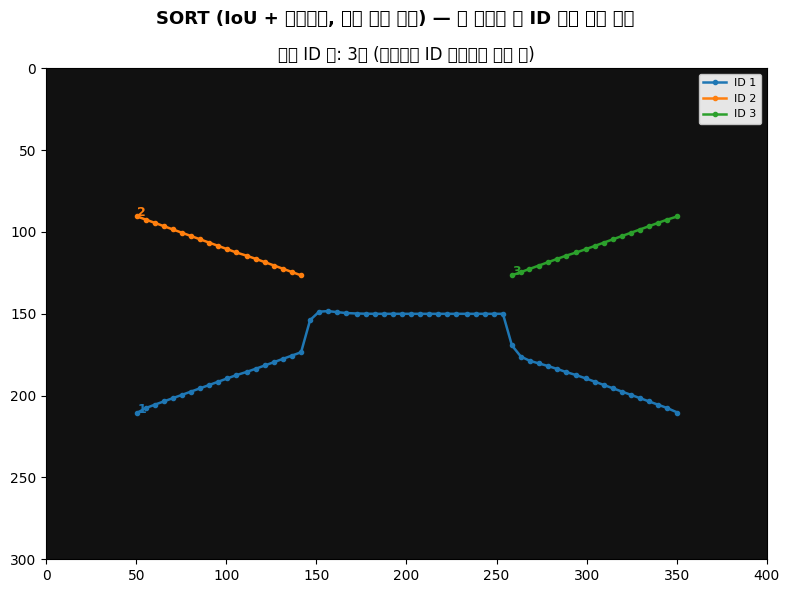

저장 완료: sort_tracking_result.png / 생성된 트랙 ID 총 개수: 3


In [7]:
sort_visualizer = TrackingVisualizer(
    title="SORT (IoU + 칼만필터, 외형 정보 없음) — 긴 가려짐 후 ID 유지 실패 확인"
)
sort_visualizer.save_trajectories(frames[0].shape[:2], sort_histories, "sort_tracking_result.png")

## 셀 5: DeepSORT 구성 — 같은 유스케이스 코드, Associator와 Gallery만

In [8]:
# 교체(OCP/LSP). MultiObjectTrackingUseCase 자체는 한 줄도 수정하지 않는다.
deepsort_tracker = MultiObjectTrackingUseCase(
    detector=ColorContourDetector(min_area=40),
    motion_model=ConstantVelocityKalmanMotionModel(process_noise=1.0, measurement_noise=1.0),
    associator=AppearanceIoUAssociator(iou_threshold=0.3, appearance_weight=0.6),
    gallery=AppearanceReidentificationGallery(max_gallery_age=30, similarity_threshold=0.85),
    max_age=MAX_AGE,
)

deepsort_histories: dict[int, list[tuple[float, float]]] = {}
for frame in frames:
    active_tracks = deepsort_tracker.process_frame(frame)
    for t in active_tracks:
        if t.history:
            deepsort_histories[t.track_id] = t.history

print(f"\n[DeepSORT] 생성된 트랙 ID 총 개수: {len(deepsort_histories)}")
if deepsort_tracker.reidentified_log:
    for attempted_new_id, recycled_id in deepsort_tracker.reidentified_log:
        print(f"  재식별 성공: 새 ID {attempted_new_id}를 만들 뻔했지만, "
              f"색상 특징이 일치해 기존 ID {recycled_id}를 재사용함")


[DeepSORT] 생성된 트랙 ID 총 개수: 2
  재식별 성공: 새 ID 3를 만들 뻔했지만, 색상 특징이 일치해 기존 ID 2를 재사용함


## 셀 6: DeepSORT 결과 시각화 및 SORT와 비교

/tmp/ipykernel_2115/3884697589.py:482: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2115/3884697589.py:482: UserWarning: Glyph 47001 (\N{HANGUL SYLLABLE RAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2115/3884697589.py:482: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2115/3884697589.py:482: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2115/3884697589.py:482: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2115/3884697589.py:482: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2115/3884697589.py:482: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt

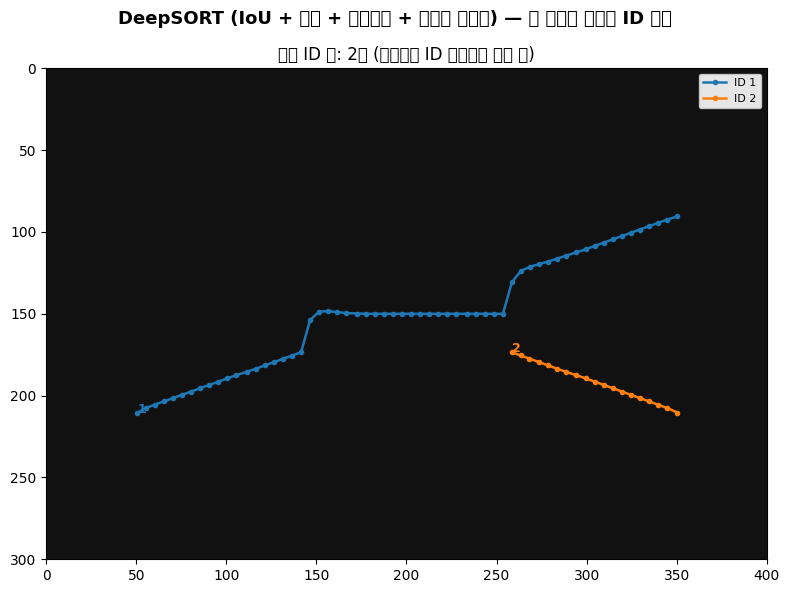

저장 완료: deepsort_tracking_result.png / 생성된 트랙 ID 총 개수: 2

=== SORT vs DeepSORT 비교 ===
SORT    : 트랙 ID 3개 생성 (max_age=6프레임보다 긴 가려짐 때문에 가려졌던 객체가 다시 나타날 때 완전히 새로운 ID를 받음)
DeepSORT: 트랙 ID 2개 생성 (재식별 갤러리가 사라지기 직전의 색상 특징을 기억해두었다가, 다시 나타난 탐지와 비교해 원래 ID를 복구함)

이것이 DeepSORT라는 이름의 핵심 의미다 — 단순 모션 예측(SORT)만으로는 긴 가려짐 이후 '이게 그 객체가 맞는지'를 알 방법이 없지만, 외형(Deep) 특징을 기억해두면 재식별(Re-Identification)이 가능해진다.


In [9]:
deepsort_visualizer = TrackingVisualizer(
    title="DeepSORT (IoU + 외형 + 칼만필터 + 재식별 갤러리) — 긴 가려짐 후에도 ID 유지"
)
deepsort_visualizer.save_trajectories(frames[0].shape[:2], deepsort_histories, "deepsort_tracking_result.png")

print("\n=== SORT vs DeepSORT 비교 ===")
print(f"SORT    : 트랙 ID {len(sort_histories)}개 생성 (max_age={MAX_AGE}프레임보다 긴 가려짐 때문에 "
      f"가려졌던 객체가 다시 나타날 때 완전히 새로운 ID를 받음)")
print(f"DeepSORT: 트랙 ID {len(deepsort_histories)}개 생성 (재식별 갤러리가 사라지기 직전의 색상 "
      f"특징을 기억해두었다가, 다시 나타난 탐지와 비교해 원래 ID를 복구함)")
print("\n이것이 DeepSORT라는 이름의 핵심 의미다 — 단순 모션 예측(SORT)만으로는 "
      "긴 가려짐 이후 '이게 그 객체가 맞는지'를 알 방법이 없지만, 외형(Deep) "
      "특징을 기억해두면 재식별(Re-Identification)이 가능해진다.")